<h1>Wine Quality Classification</h1>

<ul>
    <li>Predicting whether a wine is <strong>Low, Medium, or High quality</strong> based on its physicochemical measurements.</li>
    <li>Dataset: <strong>UCI Wine Quality Dataset</strong> (Cortez et al., 2009), containing red and white wine samples.</li>
    <li>This notebook covers the complete workflow, including <strong>data preprocessing, feature engineering, model training, and evaluation</strong>, and exports the final model used by the API.</li>
</ul>


<h3>1. Load the data</h3>

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

RED = "../../data/raw/winequality-red.csv"
WHITE = "../../data/raw/winequality-white.csv"

red = pd.read_csv(RED, sep=";")
white = pd.read_csv(WHITE, sep=";")

print("red:  ", red.shape)
print("white:", white.shape)

red:   (1599, 12)
white: (4898, 12)


<p>
    The two datasets have the same columns, so they can be combined into a single dataset.
    Before merging them, we add a <code>wine_type</code> column to identify whether each sample
    comes from red or white wine. This helps us preserve the wine type information after merging.
</p>

<h3>2. Explore the data</h3>

In [17]:
red["wine_type"] = 0    
white["wine_type"] = 1   

df = pd.concat([red, white], ignore_index=True)

df = df.rename(columns={
    "fixed acidity": "fixed_acidity",
    "volatile acidity": "volatile_acidity",
    "citric acid": "citric_acid",
    "residual sugar": "residual_sugar",
    "free sulfur dioxide": "free_sulfur_dioxide",
    "total sulfur dioxide": "total_sulfur_dioxide",
    "pH": "ph",
})

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [18]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   ph                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 660.0 KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,wine_type
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378,0.753886
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255,0.430779
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000,0.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000,1.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000,1.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000,1.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000,1.000000


<h4>Missing values</h4>

In [19]:
print(df.isnull().sum())
print("\ntotal missing values:", df.isnull().sum().sum())

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
ph                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64

total missing values: 0


<p>
    No missing values were found in the dataset, so no values needed to be filled or removed.
</p>

<h4>Duplicate rows</h4>

In [20]:
print("duplicate rows:", df.duplicated().sum())

duplicate rows: 1177


<p>
    Duplicate rows were found in the dataset, so they need to be removed.
</p>

<p>
    The dataset does not have an ID column, so identical rows cannot be distinguished as separate wine samples.
    If duplicates are kept, the same wine could appear in both the training and testing sets.
    This could make the model appear more accurate than it actually is because it would be tested on data it had already seen.
</p>


In [21]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)

print(f"{before} rows -> {len(df)} rows ({before - len(df)} duplicates removed)")

6497 rows -> 5320 rows (1177 duplicates removed)


<h3>3. The target column</h3>

In [22]:
df["quality"].value_counts().sort_index()

quality
3      30
4     206
5    1752
6    2323
7     856
8     148
9       5
Name: count, dtype: int64

<p>
    Quality scores range from 3 to 9, but the classes are highly unbalanced, with only a few wines receiving scores of 3 or 9.
    With very few samples in a class, the model may not learn that class effectively.
</p>

<p>
    Therefore, we group the quality scores into three classes using the median score of 6 as the main split point:
</p>


| Class  | Quality scores | Meaning |
|--------|----------------|---------|
| Low    | 3, 4, 5        | below the median rating |
| Medium | 6              | at the median rating |
| High   | 7, 8, 9        | above the median rating |

In [23]:

QUALITY_MAP = {3: "Low", 4: "Low", 5: "Low", 6: "Medium", 7: "High", 8: "High", 9: "High"}
CLASS_ORDER = ["Low", "Medium", "High"]

df["quality_class"] = df["quality"].map(QUALITY_MAP)

counts = df["quality_class"].value_counts().reindex(CLASS_ORDER)
print(counts)
print("\nas a percentage:")
print((counts / len(df) * 100).round(1))

quality_class
Low       1988
Medium    2323
High      1009
Name: count, dtype: int64

as a percentage:
quality_class
Low       37.4
Medium    43.7
High      19.0
Name: count, dtype: float64


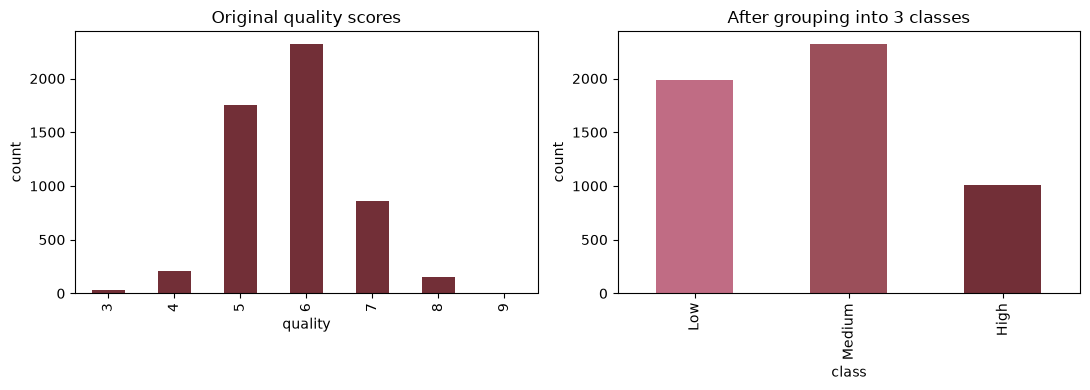

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

df["quality"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0],
    color="#722F37"
)

axes[0].set_title("Original quality scores")
axes[0].set_xlabel("quality")
axes[0].set_ylabel("count")

counts.plot(
    kind="bar",
    ax=axes[1],
    color=["#C06C84", "#9B4F5A", "#722F37"]
)

axes[1].set_title("After grouping into 3 classes")
axes[1].set_xlabel("class")
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

<p>
    The three classes are still somewhat unbalanced but are suitable for training.
    <strong>Medium</strong> is the largest class at around 44%, while <strong>High</strong> is the smallest at around 19%.
</p>

<p>
    If the model simply predicted <strong>Medium</strong> for every wine, it would achieve about 44% accuracy.
    Therefore, 44% is our <strong>baseline accuracy</strong>, and the trained model should perform better than this.
</p>


## 4. Measurements relate to quality?

In [25]:
correlations = df.corr(numeric_only=True)["quality"].drop(["quality", "quality_class"], errors="ignore")
correlations.sort_values(ascending=False)

alcohol                 0.469422
wine_type               0.114809
citric_acid             0.097954
free_sulfur_dioxide     0.054002
sulphates               0.041884
ph                      0.039733
total_sulfur_dioxide   -0.050296
residual_sugar         -0.056830
fixed_acidity          -0.080092
chlorides              -0.202137
volatile_acidity       -0.265205
density                -0.326434
Name: quality, dtype: float64

`alcohol` has the strongest positive correlation with quality, and
`volatile_acidity` the strongest negative one. Both make sense: volatile
acidity is acetic acid, which is what makes wine taste of vinegar.

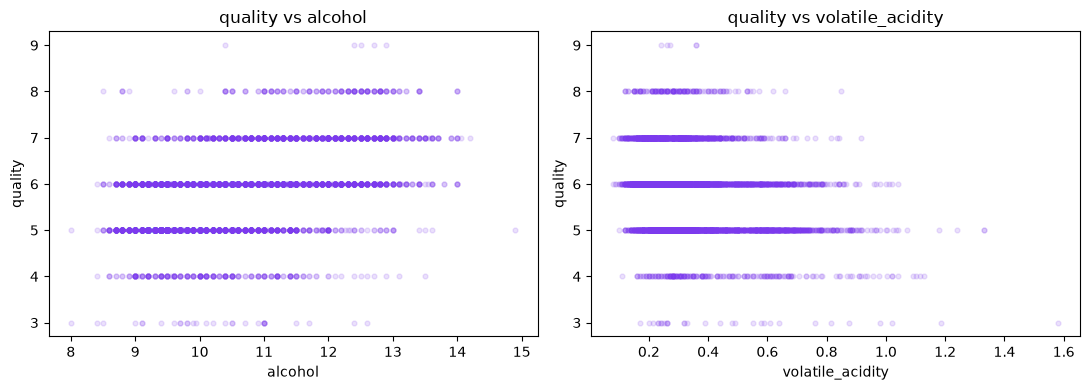

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, col in zip(axes, ["alcohol", "volatile_acidity"]):
    ax.scatter(df[col], df["quality"], alpha=0.15, s=12, color="#7c3aed")
    ax.set_xlabel(col)
    ax.set_ylabel("quality")
    ax.set_title(f"quality vs {col}")

plt.tight_layout()
plt.show()

In [27]:
# The same thing as averages, which is easier to read than the scatter plot.
df.groupby("quality_class")[["alcohol", "volatile_acidity", "density"]].mean().reindex(CLASS_ORDER)

,alcohol,volatile_acidity,density
quality_class,,,
Low,9.912909,0.402915,0.995638
Medium,10.649060,0.315626,0.994377
High,11.573175,0.293930,0.992727


High quality wines have noticeably more alcohol and less volatile acidity on
average. The scatter plots are hard to read because quality only takes whole
number values, so the points sit in horizontal lines.

## 5. Feature engineering and split

In [28]:
from sklearn.model_selection import train_test_split

# Four domain-based features derived from the original measurements.
df["total_acidity"] = df["fixed_acidity"] + df["volatile_acidity"] + df["citric_acid"]
df["bound_sulfur_dioxide"] = df["total_sulfur_dioxide"] - df["free_sulfur_dioxide"]
df["free_sulfur_ratio"] = df["free_sulfur_dioxide"] / df["total_sulfur_dioxide"]
df["alcohol_density_ratio"] = df["alcohol"] / df["density"]

FEATURES = [
    "fixed_acidity", "volatile_acidity", "citric_acid", "residual_sugar",
    "chlorides", "free_sulfur_dioxide", "total_sulfur_dioxide", "density",
    "ph", "sulphates", "alcohol", "wine_type",
    "total_acidity", "bound_sulfur_dioxide", "free_sulfur_ratio",
    "alcohol_density_ratio",
]

X = df[FEATURES]
y = df["quality_class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train:", X_train.shape)
print("test: ", X_test.shape)

train: (4256, 16)
test:  (1064, 16)


Two things to note about this split.

**`quality` is not in `FEATURES`.** The target `quality_class` was calculated
from `quality`, so leaving `quality` in the input would be giving the model the
answer. It would score close to 100% and mean nothing.

**`stratify=y`** keeps the same class proportions in the training and test
sets. Without it, a random split could leave too few High wines in the test set
to measure anything.

## 6. Train the models

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
}

results = {}
for name, model in models.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    pipe.fit(X_train, y_train)

    accuracy = accuracy_score(y_test, pipe.predict(X_test))
    results[name] = (pipe, accuracy)
    print(f"{name:22s} accuracy = {accuracy:.4f}")

Logistic Regression    accuracy = 0.6034
Random Forest          accuracy = 0.6457


The measurements are on completely different scales `total_sulfur_dioxide`
runs into the hundreds while `density` is around 1.0. Logistic Regression is
affected by that, so the values are standardised first. Random Forest is not
affected, but putting both models through the same pipeline keeps the
comparison fair.

In [30]:
best_name = max(results, key=lambda name: results[name][1])
best_model, best_accuracy = results[best_name]

print(f"best model: {best_name} ({best_accuracy:.4f})")
print(f"baseline (always predict Medium): {(y_test == 'Medium').mean():.4f}")

best model: Random Forest (0.6457)
baseline (always predict Medium): 0.4370
